# **Análisis de relaciones entre predictores y targets**

Este notebook explora las asociaciones entre los predictores preparados para el análisis exploratorio del **MITSUI&CO. Commodity Prediction Challenge** y los targets del reto. El objetivo no es construir modelos ni eliminar columnas: el resultado esperado es evidencia ordenada que sirva de insumo para una etapa posterior de selección de características.

Al cierre del notebook se responde a tres preguntas exploratorias:

1. ¿Qué predictores o familias de predictores muestran asociaciones relativamente más fuertes con los targets?
2. ¿Qué predictores parecen describir información muy similar o repetida?
3. ¿Qué predictores muestran poca señal aparente?

Una asociación observada no demuestra causalidad ni poder predictivo. Todas las conclusiones se describen como **candidatos** que deberán contrastarse posteriormente con modelos.

## **Reglas de trabajo**

- Solo se usan `data/processed/train_eda.csv`, `data/raw/train_labels.csv` y `data/raw/target_pairs.csv`. No se toca `data/raw` ni el notebook `01_analisis_exploratorio.ipynb`.
- No se eliminan filas globalmente ni se imputan valores faltantes: cada cálculo usa las observaciones completas de las columnas involucradas y reporta cuántas fueron.
- No se generan datasets procesados ni transformaciones persistentes.
- No se construyen ni evalúan modelos.
- `date_id` se conserva durante todo el análisis para validar la alineación temporal.

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")


def encontrar_raiz_proyecto() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "data" / "raw").exists():
            return candidato
    raise FileNotFoundError("No se encontro data/raw en ningun directorio superior.")


RAIZ = encontrar_raiz_proyecto()
RUTAS = {
    "train_eda": RAIZ / "data" / "processed" / "train_eda.csv",
    "train_labels": RAIZ / "data" / "raw" / "train_labels.csv",
    "target_pairs": RAIZ / "data" / "raw" / "target_pairs.csv",
}
RUTAS

{'train_eda': PosixPath('/Users/jbenitez/Documents/GitHub/Proyecto_2_EDA_Data_Science/data/processed/train_eda.csv'),
 'train_labels': PosixPath('/Users/jbenitez/Documents/GitHub/Proyecto_2_EDA_Data_Science/data/raw/train_labels.csv'),
 'target_pairs': PosixPath('/Users/jbenitez/Documents/GitHub/Proyecto_2_EDA_Data_Science/data/raw/target_pairs.csv')}

In [2]:
train_eda = pd.read_csv(RUTAS["train_eda"])
train_labels = pd.read_csv(RUTAS["train_labels"])
target_pairs = pd.read_csv(RUTAS["target_pairs"])

pred_cols = [c for c in train_eda.columns if c != "date_id"]
targ_cols = [c for c in train_labels.columns if c != "date_id"]

print(f"train_eda:     {train_eda.shape[0]:,} filas, {len(pred_cols):,} predictores")
print(f"train_labels:  {train_labels.shape[0]:,} filas, {len(targ_cols):,} targets")
print(f"target_pairs:  {target_pairs.shape[0]:,} filas")

train_eda:     1,961 filas, 552 predictores
train_labels:  1,961 filas, 424 targets
target_pairs:  424 filas


## **Primera sección: validar la base analítica**

Antes de calcular cualquier asociación se verifica que los tres archivos estén alineados y sean consistentes entre sí. Si alguna verificación falla, el análisis se detiene aquí: no se inventa una alineación alternativa.

In [3]:
resultados_validacion = []


def verificar(nombre: str, condicion: bool, detalle: str) -> None:
    resultados_validacion.append(
        {"verificación": nombre, "resultado": "OK" if condicion else "FALLO", "detalle": detalle}
    )


# 1. Mismos date_id, mismo orden, sin duplicados entre train_eda y train_labels.
mismo_orden = train_eda["date_id"].equals(train_labels["date_id"])
verificar(
    "date_id alineados (train_eda vs train_labels)",
    mismo_orden,
    f"{train_eda['date_id'].nunique():,} date_id únicos en train_eda, "
    f"{train_labels['date_id'].nunique():,} en train_labels",
)
verificar(
    "train_eda sin date_id duplicados",
    not train_eda["date_id"].duplicated().any(),
    f"{train_eda['date_id'].duplicated().sum()} duplicados",
)
verificar(
    "train_labels sin date_id duplicados",
    not train_labels["date_id"].duplicated().any(),
    f"{train_labels['date_id'].duplicated().sum()} duplicados",
)

# 2. Cada columna de target aparece exactamente una vez en target_pairs.
conteo_targets = target_pairs["target"].value_counts()
targets_repetidos = conteo_targets[conteo_targets > 1]
targets_sin_metadata = sorted(set(targ_cols) - set(target_pairs["target"]))
verificar(
    "cada target aparece exactamente una vez en target_pairs",
    len(targets_repetidos) == 0 and set(targ_cols) == set(target_pairs["target"]),
    f"{len(targets_repetidos)} targets repetidos, {len(targets_sin_metadata)} sin metadata",
)

# 3. Cada target tiene lag y expresión pair válidos.
lag_valido = target_pairs["lag"].notna().all() and target_pairs["lag"].gt(0).all()
pair_valido = target_pairs["pair"].notna().all() and target_pairs["pair"].str.len().gt(0).all()
verificar("todos los targets tienen lag válido", lag_valido, f"lags observados: {sorted(target_pairs['lag'].unique())}")
verificar("todos los targets tienen expresión pair no vacía", pair_valido, "sin valores nulos ni vacíos")

# 4. Los predictores referenciados en pair existen en train_eda, salvo excepción documentada.
instrumentos_en_pairs = set()
for expresion in target_pairs["pair"]:
    for parte in re.split(r"\s*-\s*", expresion):
        instrumentos_en_pairs.add(parte.strip())

instrumentos_ausentes = sorted(instrumentos_en_pairs - set(pred_cols))
# La única exclusión documentada por la preparación de datos es la familia US_Stock_GOLD,
# retirada en 01_exclusion_sin_cobertura.py por falta de cobertura temporal.
ausentes_no_documentados = [i for i in instrumentos_ausentes if "GOLD" not in i]
verificar(
    "predictores de target_pairs presentes en train_eda (o ausencia documentada)",
    len(ausentes_no_documentados) == 0,
    f"{len(instrumentos_ausentes)} ausentes en total, {len(ausentes_no_documentados)} sin documentar: {ausentes_no_documentados}",
)

tabla_dimensiones = pd.DataFrame(
    [
        {"archivo": "train_eda.csv", "filas": train_eda.shape[0], "columnas": train_eda.shape[1]},
        {"archivo": "train_labels.csv", "filas": train_labels.shape[0], "columnas": train_labels.shape[1]},
        {"archivo": "target_pairs.csv", "filas": target_pairs.shape[0], "columnas": target_pairs.shape[1]},
    ]
)
tabla_validacion = pd.DataFrame(resultados_validacion)

display(tabla_dimensiones)
display(tabla_validacion)

assert (tabla_validacion["resultado"] == "OK").all(), "Se detuvo el análisis: al menos una verificación de alineación falló."
print("Todas las verificaciones se cumplen: se procede con la alineación entregada, sin modificarla.")

,archivo,filas,columnas
0,train_eda.csv,1961,553
1,train_labels.csv,1961,425
2,target_pairs.csv,424,3


,verificación,resultado,detalle
0,date_id alineados (train_eda vs train_labels),OK,"1,961 date_id únicos en train_eda, 1,961 en train_labels"
1,train_eda sin date_id duplicados,OK,0 duplicados
2,train_labels sin date_id duplicados,OK,0 duplicados
3,cada target aparece exactamente una vez en target_pairs,OK,"0 targets repetidos, 0 sin metadata"
4,todos los targets tienen lag válido,OK,"lags observados: [np.int64(1), np.int64(2), np.int64(3),..."
5,todos los targets tienen expresión pair no vacía,OK,sin valores nulos ni vacíos
6,predictores de target_pairs presentes en train_eda (o au...,OK,"0 ausentes en total, 0 sin documentar: []"


Todas las verificaciones se cumplen: se procede con la alineación entregada, sin modificarla.


Las tres fuentes están alineadas por `date_id`, sin duplicados, y cada target cuenta con exactamente una fila de metadata en `target_pairs.csv` con `lag` y `pair` válidos. La única ausencia detectada entre los instrumentos referenciados en `pair` corresponde a la familia `US_Stock_GOLD`, ya documentada como excluida por `01_exclusion_sin_cobertura.py` por falta de cobertura temporal. Con esto, el resto del análisis puede usar `date_id` como llave de alineación temporal sin ajustes adicionales.

## **Segunda sección: entender los targets antes de correlacionar**

Antes de correlacionar es necesario saber qué representa cada target: su rezago (`lag`), si describe el retorno de un solo instrumento o la diferencia entre dos, y qué mercados involucra. Esto hace interpretable cualquier ranking posterior.

In [4]:
def dividir_pair(expresion: str):
    partes = [p.strip() for p in re.split(r"\s*-\s*", expresion)]
    tipo = "retorno" if len(partes) == 1 else "diferencia" if len(partes) == 2 else "otro"
    return tipo, partes


target_pairs[["tipo_relacion", "instrumentos"]] = target_pairs["pair"].apply(
    lambda p: pd.Series(dividir_pair(p))
)

resumen_lag = target_pairs["lag"].value_counts().sort_index().rename("n_targets").to_frame()
resumen_tipo = target_pairs["tipo_relacion"].value_counts().rename("n_targets").to_frame()

print("Targets por lag:")
display(resumen_lag)
print("Targets por tipo de relación:")
display(resumen_tipo)

Targets por lag:


,n_targets
lag,
1,106
2,106
3,106
4,106


Targets por tipo de relación:


,n_targets
tipo_relacion,
diferencia,420
retorno,4


In [5]:
def mercado_de_instrumento(nombre: str) -> str:
    if nombre.startswith("LME_"):
        return "London Metal Exchange (LME)"
    if nombre.startswith("JPX_"):
        return "Futuros JPX"
    if nombre.startswith("US_Stock_"):
        return "Acciones de Estados Unidos"
    if nombre.startswith("FX_"):
        return "Divisas (FX)"
    return "Desconocido"


mercados_en_targets = target_pairs["instrumentos"].apply(lambda lst: {mercado_de_instrumento(i) for i in lst})
conteo_mercados = pd.Series([m for s in mercados_en_targets for m in s]).value_counts().rename("n_apariciones").to_frame()
print("Mercados presentes en las expresiones de los targets (un target puede tocar más de uno):")
display(conteo_mercados)

ejemplo_diferencia = target_pairs[target_pairs["tipo_relacion"] == "diferencia"].iloc[0]
ejemplo_retorno = target_pairs[target_pairs["tipo_relacion"] == "retorno"].iloc[0]
print("Ejemplo de diferencia entre instrumentos:")
display(ejemplo_diferencia.to_frame().T)
print("Ejemplo de retorno de un solo instrumento:")
display(ejemplo_retorno.to_frame().T)

Mercados presentes en las expresiones de los targets (un target puede tocar más de uno):


,n_apariciones
London Metal Exchange (LME),287
Acciones de Estados Unidos,270
Futuros JPX,145
Divisas (FX),134


Ejemplo de diferencia entre instrumentos:


,target,lag,pair,tipo_relacion,instrumentos
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close,diferencia,"[LME_PB_Close, US_Stock_VT_adj_close]"


Ejemplo de retorno de un solo instrumento:


,target,lag,pair,tipo_relacion,instrumentos
0,target_0,1,US_Stock_VT_adj_close,retorno,[US_Stock_VT_adj_close]


La mayoría de los targets (420 de 424) se define como la **diferencia** entre dos instrumentos, y solo 4 como el **retorno** de un único instrumento; los cuatro lags (1 a 4) están igualmente representados (106 targets cada uno). Los mercados de acciones de EE. UU. y de divisas son los que más aparecen en las expresiones `pair`, seguidos de JPX y LME.

Sobre el desplazamiento por `lag`: la documentación pública de la competencia no fue accesible de forma completa en este entorno de trabajo (los intentos de consulta a la página de datos de Kaggle solo devolvieron el título de la página, sin el contenido técnico). Por esta razón, siguiendo la regla del enunciado, **no se desplazan manualmente las filas de predictores** usando `lag`: las asociaciones de las siguientes secciones se calculan directamente sobre los `date_id` ya alineados en `train_eda.csv` y `train_labels.csv`, tal como fueron entregados. Esta es una limitación explícita del análisis: si la alineación entregada ya incorpora el rezago, el procedimiento es correcto; si no lo incorpora, las correlaciones deben leerse como asociaciones contemporáneas por `date_id` y no como relaciones predictor(t) → target(t+lag) confirmadas.

## **Tercera sección: asociaciones predictor–target**

Se calcula la correlación de Spearman entre cada uno de los 552 predictores y cada uno de los 424 targets, usando en cada par únicamente las observaciones donde ambas variables están presentes. Spearman es apropiada como medida exploratoria porque resume relaciones monótonas sin suponer linealidad ni una escala común entre variables que representan precios, retornos y volúmenes de naturaleza distinta.

In [6]:
combinado = pd.concat([train_eda[pred_cols], train_labels[targ_cols]], axis=1)

correlacion_completa = combinado.corr(method="spearman")

no_nulo = combinado.notna().to_numpy(dtype=np.int32)
matriz_conteos = no_nulo.T @ no_nulo
conteos_completos = pd.DataFrame(matriz_conteos, index=combinado.columns, columns=combinado.columns)

corr_predictor_target = correlacion_completa.loc[pred_cols, targ_cols]
conteo_predictor_target = conteos_completos.loc[pred_cols, targ_cols]

asociaciones = corr_predictor_target.stack().rename("spearman").reset_index()
asociaciones.columns = ["predictor", "target", "spearman"]
asociaciones["abs_spearman"] = asociaciones["spearman"].abs()

n_obs = conteo_predictor_target.stack().rename("n_obs").reset_index()
n_obs.columns = ["predictor", "target", "n_obs"]

asociaciones = asociaciones.merge(n_obs, on=["predictor", "target"]).merge(
    target_pairs[["target", "lag", "pair", "tipo_relacion"]], on="target", how="left"
)

print(f"Pares predictor-target evaluados: {len(asociaciones):,}")
print("Observaciones utilizadas por par (mínimo requerido de completitud pairwise, sin imputación):")
display(asociaciones["n_obs"].describe().to_frame("n_obs"))

Pares predictor-target evaluados: 234,048
Observaciones utilizadas por par (mínimo requerido de completitud pairwise, sin imputación):


,n_obs
count,234048.000000
mean,1700.301750
std,89.159284
min,1516.000000
25%,1661.000000
50%,1717.000000
75%,1749.000000
max,1961.000000


Cada par predictor–target se evalúa únicamente con las filas donde ambas columnas están presentes: el número de observaciones usadas varía por par (mediana en torno a los 1,700 días de los 1,961 disponibles) y queda registrado en la tabla `asociaciones`, en vez de completarse con imputación.

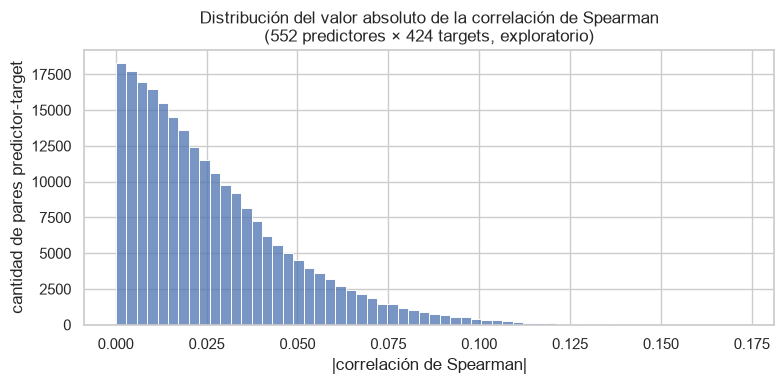

,abs_spearman
count,2.340480e+05
mean,2.650351e-02
std,2.198036e-02
min,1.583482e-09
25%,9.551560e-03
50%,2.101414e-02
75%,3.763724e-02
max,1.724831e-01


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(asociaciones["abs_spearman"], bins=60, ax=ax, color="#4C72B0")
ax.set_title("Distribución del valor absoluto de la correlación de Spearman\n(552 predictores × 424 targets, exploratorio)")
ax.set_xlabel("|correlación de Spearman|")
ax.set_ylabel("cantidad de pares predictor-target")
plt.tight_layout()
plt.show()

display(asociaciones["abs_spearman"].describe().to_frame("abs_spearman"))

La distribución está concentrada muy cerca de cero: la mediana del valor absoluto de la correlación es de apenas ~0.02 y el máximo observado en los más de 234,000 pares no llega a 0.18. Esto es consistente con la dificultad conocida de predecir retornos financieros a partir de niveles y volúmenes de otros instrumentos, y es la primera evidencia de que **ningún predictor individual domina de forma aislada**: cualquier señal útil probablemente sea débil y deba combinarse con otras variables o capturarse con relaciones no monótonas, algo que este análisis exploratorio no puede descartar.

In [8]:
top_por_lag = (
    asociaciones.sort_values("abs_spearman", ascending=False)
    .groupby("lag")
    .head(3)
    .sort_values(["lag", "abs_spearman"], ascending=[True, False])
)
display(top_por_lag[["lag", "predictor", "target", "pair", "spearman", "n_obs"]].reset_index(drop=True))

,lag,predictor,target,pair,spearman,n_obs
0,1,JPX_Gold_Mini_Futures_open_interest,target_50,US_Stock_SLB_adj_close - JPX_Gold_Standard_Futures_Close,-0.088553,1538
1,1,US_Stock_EOG_adj_volume,target_67,JPX_Gold_Standard_Futures_Close - US_Stock_HAL_adj_close,-0.084169,1561
2,1,US_Stock_LQD_adj_close,target_61,LME_AH_Close - US_Stock_BNDX_adj_close,0.081953,1732
3,2,LME_PB_Close,target_188,FX_USDCHF - LME_PB_Close,0.124607,1824
4,2,US_Stock_EOG_adj_volume,target_121,US_Stock_EOG_adj_close - JPX_Gold_Standard_Futures_Close,0.123009,1550
5,2,FX_CADUSD,target_150,LME_AH_Close - US_Stock_WPM_adj_close,0.122242,1768
6,3,LME_PB_Close,target_231,LME_PB_Close - FX_USDJPY,-0.156118,1824
7,3,LME_PB_Close,target_236,LME_PB_Close - FX_CHFJPY,-0.145292,1824
8,3,US_Stock_LQD_adj_close,target_220,LME_AH_Close - US_Stock_BNDX_adj_close,0.142984,1717
9,4,LME_PB_Close,target_406,FX_USDCHF - LME_PB_Close,0.172483,1825


La tabla anterior muestra, para cada uno de los cuatro lags, los tres pares predictor–target con mayor correlación absoluta (no un umbral arbitrario). `LME_PB_Close` aparece de forma recurrente entre los mejores posicionados en varios lags, lo que lo convierte en un candidato a revisar con atención en la sección de síntesis.

In [9]:
def mercado_medicion(nombre: str):
    if nombre.startswith("LME_"):
        return "London Metal Exchange (LME)", "Close"
    if nombre.startswith("JPX_"):
        for suf in ["_settlement_price", "_open_interest", "_Open", "_High", "_Low", "_Close", "_Volume"]:
            if nombre.endswith(suf):
                return "Futuros JPX", suf[1:]
    if nombre.startswith("US_Stock_"):
        for suf in ["_adj_open", "_adj_high", "_adj_low", "_adj_close", "_adj_volume"]:
            if nombre.endswith(suf):
                return "Acciones de Estados Unidos", suf[1:]
    if nombre.startswith("FX_"):
        return "Divisas (FX)", "tasa_de_cambio"
    return "Desconocido", "desconocida"


meta_predictores = pd.DataFrame(
    [(c, *mercado_medicion(c)) for c in pred_cols], columns=["predictor", "mercado", "medición"]
)

top_global = asociaciones.sort_values("abs_spearman", ascending=False).head(20).merge(
    meta_predictores, on="predictor", how="left"
)
top_global["predictor_es_componente_del_target"] = top_global.apply(
    lambda fila: fila["predictor"] in fila["pair"], axis=1
)

display(
    top_global[
        [
            "predictor", "mercado", "medición", "target", "lag", "pair",
            "spearman", "n_obs", "predictor_es_componente_del_target",
        ]
    ].reset_index(drop=True)
)

,predictor,mercado,medición,target,lag,pair,spearman,n_obs,predictor_es_componente_del_target
0,LME_PB_Close,London Metal Exchange (LME),Close,target_406,4,FX_USDCHF - LME_PB_Close,0.172483,1825,True
1,LME_PB_Close,London Metal Exchange (LME),Close,target_345,4,FX_CADJPY - LME_PB_Close,0.156763,1825,True
2,LME_PB_Close,London Metal Exchange (LME),Close,target_231,3,LME_PB_Close - FX_USDJPY,-0.156118,1824,True
3,LME_PB_Close,London Metal Exchange (LME),Close,target_376,4,US_Stock_TIP_adj_close - LME_PB_Close,0.155799,1741,True
4,US_Stock_LQD_adj_low,Acciones de Estados Unidos,adj_low,target_410,4,FX_EURUSD - LME_AH_Close,-0.155646,1807,False
5,US_Stock_LQD_adj_close,Acciones de Estados Unidos,adj_close,target_410,4,FX_EURUSD - LME_AH_Close,-0.155368,1807,False
6,US_Stock_LQD_adj_open,Acciones de Estados Unidos,adj_open,target_410,4,FX_EURUSD - LME_AH_Close,-0.153848,1806,False
7,US_Stock_VCIT_adj_low,Acciones de Estados Unidos,adj_low,target_410,4,FX_EURUSD - LME_AH_Close,-0.153845,1807,False
8,US_Stock_VCIT_adj_close,Acciones de Estados Unidos,adj_close,target_410,4,FX_EURUSD - LME_AH_Close,-0.153287,1806,False
9,US_Stock_LQD_adj_high,Acciones de Estados Unidos,adj_high,target_410,4,FX_EURUSD - LME_AH_Close,-0.153102,1807,False


Los 20 pares más asociados (por ranking de valor absoluto de Spearman, no por un umbral fijo) provienen sobre todo de acciones de EE. UU. y de `LME_PB_Close`. La columna `predictor_es_componente_del_target` es una regla de lectura útil, no una selección final: cuando es verdadera (por ejemplo `LME_PB_Close` frente a `target_406`, definido como `FX_USDCHF - LME_PB_Close`), parte de la asociación observada puede deberse a que el predictor participa directamente en la construcción del target, y no a una relación predictiva independiente. Los pares donde esa columna es falsa —como varios ETFs de bonos (`LQD`, `VCIT`, `BNDX`, `EMB`) asociados con `target_410`— son candidatos más interesantes para validación posterior, porque la asociación no es mecánica.

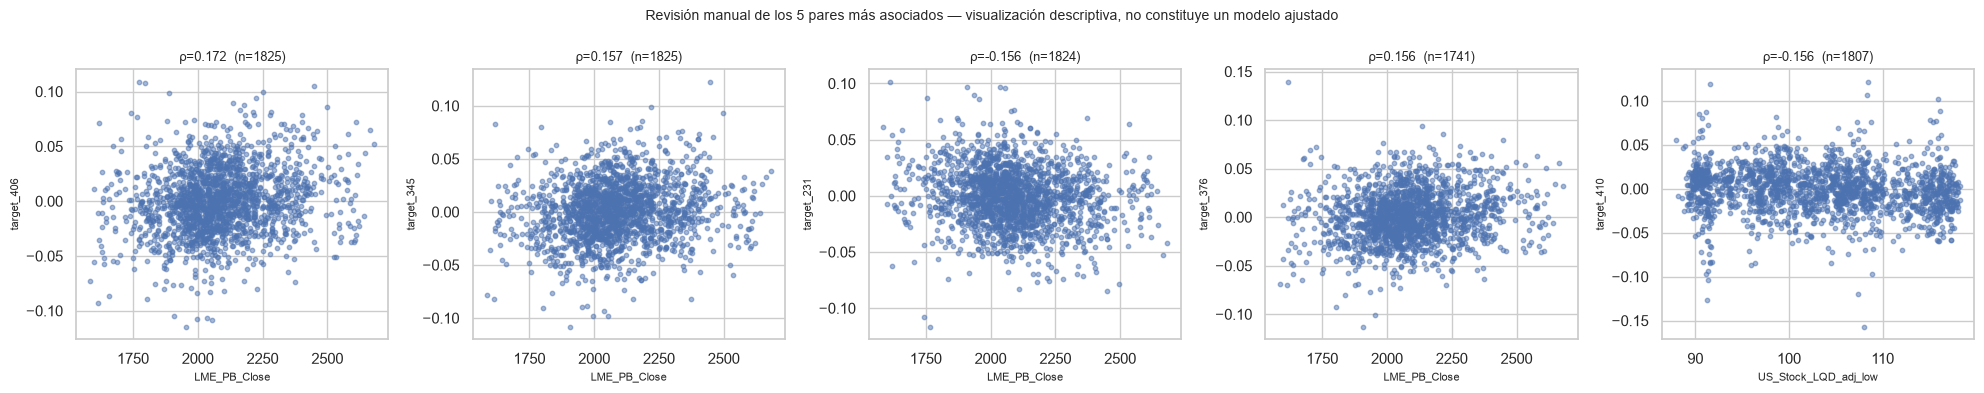

In [10]:
top5 = asociaciones.sort_values("abs_spearman", ascending=False).head(5).reset_index(drop=True)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (_, fila) in zip(axes, top5.iterrows()):
    datos_par = pd.concat(
        [train_eda[["date_id", fila["predictor"]]], train_labels[[fila["target"]]]], axis=1
    ).dropna()
    ax.scatter(datos_par[fila["predictor"]], datos_par[fila["target"]], s=10, alpha=0.5)
    ax.set_xlabel(fila["predictor"], fontsize=8)
    ax.set_ylabel(fila["target"], fontsize=8)
    ax.set_title(f"ρ={fila['spearman']:.3f}  (n={fila['n_obs']})", fontsize=9)

fig.suptitle(
    "Revisión manual de los 5 pares más asociados — visualización descriptiva, no constituye un modelo ajustado",
    fontsize=10,
)
plt.tight_layout()
plt.show()

Los dispersogramas confirman lo que sugiere la correlación: existe una tendencia monótona débil pero visible en cada caso, con dispersión considerable alrededor de esa tendencia. Ninguno de los cinco pares muestra una relación suficientemente ajustada como para sugerir poder predictivo por sí solo; son **candidatos a evaluarse dentro de un modelo**, no una relación validada.

## **Cuarta sección: redundancia entre predictores**

Aquí se compara cada predictor contra los demás predictores (no contra los targets) para detectar información posiblemente repetida. Se reutiliza la misma matriz de Spearman calculada arriba, ya que incluye el bloque predictor–predictor.

In [11]:
corr_predictor_predictor = correlacion_completa.loc[pred_cols, pred_cols]
valores = corr_predictor_predictor.to_numpy()
i_sup, j_sup = np.triu_indices(len(pred_cols), k=1)
pares_valores = valores[i_sup, j_sup]

UMBRAL_FUERTE = 0.9  # regla de lectura para agrupar candidatos, no un criterio de eliminación
n_pares = len(pares_valores)
n_fuertes_pos = int((pares_valores >= UMBRAL_FUERTE).sum())
n_fuertes_neg = int((pares_valores <= -UMBRAL_FUERTE).sum())

print(f"Pares de predictores evaluados: {n_pares:,}")
print(f"Con correlación positiva fuerte (>= {UMBRAL_FUERTE}): {n_fuertes_pos:,} ({n_fuertes_pos / n_pares:.2%})")
print(f"Con correlación negativa fuerte (<= -{UMBRAL_FUERTE}): {n_fuertes_neg:,} ({n_fuertes_neg / n_pares:.2%})")

Pares de predictores evaluados: 152,076
Con correlación positiva fuerte (>= 0.9): 6,426 (4.23%)
Con correlación negativa fuerte (<= -0.9): 76 (0.05%)


Alrededor de un 4.2% de los pares de predictores comparte una correlación positiva fuerte (>= 0.9), y menos de un 0.1% una correlación negativa igual de fuerte. Esto **no implica que deban eliminarse**: solo señala que buena parte del espacio de predictores describe información posiblemente repetida y que conviene revisarla por familia antes de decidir qué combinación probar en un modelo.

In [12]:
mediciones_precio = ["adj_open", "adj_high", "adj_low", "adj_close"]
info_us = meta_predictores[
    (meta_predictores["mercado"] == "Acciones de Estados Unidos") & (meta_predictores["medición"].isin(mediciones_precio))
].copy()
info_us["instrumento"] = info_us.apply(
    lambda fila: fila["predictor"][len("US_Stock_"):-len("_" + fila["medición"])], axis=1
)

resumen_familias = []
for instrumento, grupo in info_us.groupby("instrumento"):
    columnas = grupo["predictor"].tolist()
    if len(columnas) < 2:
        continue
    sub = corr_predictor_predictor.loc[columnas, columnas].to_numpy()
    i2, j2 = np.triu_indices(len(columnas), k=1)
    resumen_familias.append(
        {"instrumento": instrumento, "n_mediciones": len(columnas), "corr_media": sub[i2, j2].mean(), "corr_mínima": sub[i2, j2].min()}
    )

resumen_familias = pd.DataFrame(resumen_familias)
print("Redundancia dentro de la familia apertura/máximo/mínimo/cierre, por instrumento de acciones de EE. UU.:")
display(resumen_familias["corr_media"].describe().to_frame("corr_media"))
print("Instrumentos con menor redundancia interna (aun así muy alta):")
display(resumen_familias.sort_values("corr_media").head(5).reset_index(drop=True))

Redundancia dentro de la familia apertura/máximo/mínimo/cierre, por instrumento de acciones de EE. UU.:


,corr_media
count,94.000000
mean,0.998753
std,0.000663
min,0.996294
25%,0.998596
50%,0.998946
75%,0.999204
max,0.999549


Instrumentos con menor redundancia interna (aun así muy alta):


,instrumento,n_mediciones,corr_media,corr_mínima
0,AG,4,0.996294,0.993689
1,EWZ,4,0.996458,0.993153
2,HL,4,0.996610,0.993560
3,NUGT,4,0.996981,0.995413
4,PAAS,4,0.997002,0.995169


La correlación media dentro de la familia apertura/máximo/mínimo/cierre de un mismo instrumento está por encima de 0.99 en prácticamente todos los casos, incluso en los instrumentos "menos redundantes" del conjunto. Estas cuatro columnas por instrumento son **candidatas fuertes a evaluación conjunta**: probablemente aportan la misma información de nivel de precio, y probar las cuatro por separado en un modelo agrega redundancia más que señal nueva.

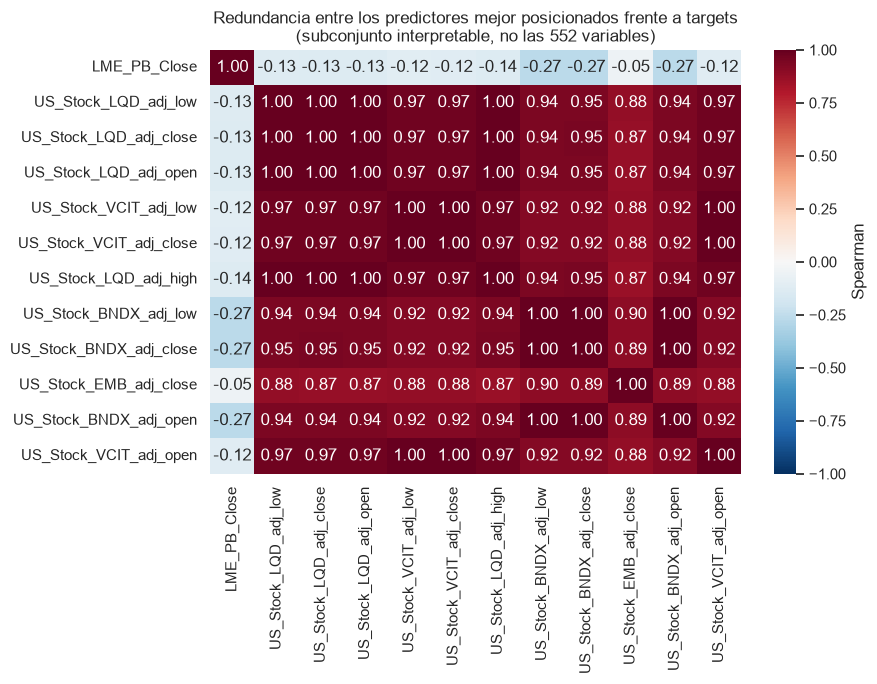

In [13]:
predictores_top = pd.unique(top_global["predictor"])[:12]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_predictor_predictor.loc[predictores_top, predictores_top],
    cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "Spearman"},
)
ax.set_title("Redundancia entre los predictores mejor posicionados frente a targets\n(subconjunto interpretable, no las 552 variables)")
plt.tight_layout()
plt.show()

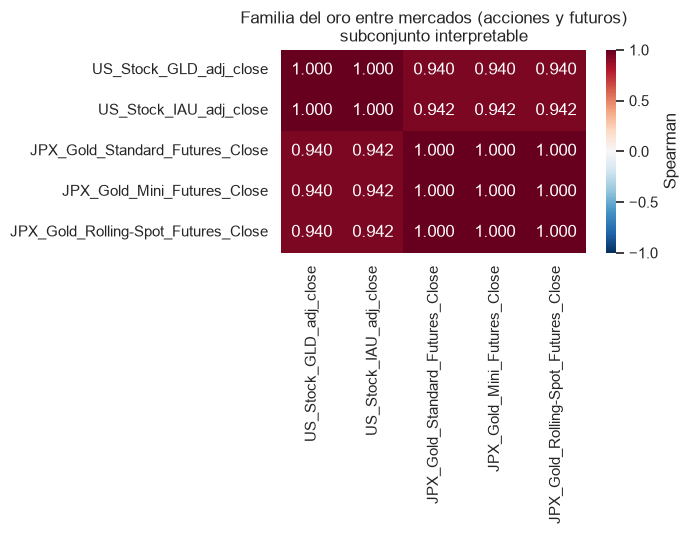

In [14]:
familia_oro = [
    "US_Stock_GLD_adj_close", "US_Stock_IAU_adj_close",
    "JPX_Gold_Standard_Futures_Close", "JPX_Gold_Mini_Futures_Close", "JPX_Gold_Rolling-Spot_Futures_Close",
]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr_predictor_predictor.loc[familia_oro, familia_oro],
    cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".3f", ax=ax, cbar_kws={"label": "Spearman"},
)
ax.set_title("Familia del oro entre mercados (acciones y futuros)\nsubconjunto interpretable")
plt.tight_layout()
plt.show()

El primer mapa de calor muestra que varios de los predictores mejor posicionados frente a los targets también están muy correlacionados entre sí (por ejemplo, distintos ETFs de bonos), lo que sugiere que aportan una señal parecida y no independiente. El segundo mapa, centrado en instrumentos ligados al oro en distintos mercados (acciones y futuros JPX), muestra correlaciones por encima de 0.99 entre casi todos los pares: son **candidatos a evaluación conjunta** porque probablemente describen el mismo movimiento de precio subyacente, aunque se negocien en mercados distintos.

## **Quinta sección: clasificación de candidatos**

Se cierra con una tabla de síntesis por categoría, construida a partir de los resultados ya calculados, en vez de una lista extensa de columnas individuales.

In [15]:
candidatos_senal = (
    top_global.drop_duplicates("predictor")
    .head(10)[["predictor", "mercado", "medición", "target", "spearman", "n_obs"]]
    .reset_index(drop=True)
)
candidatos_senal.columns = ["variable", "mercado", "medición", "target_relacionado", "correlación_spearman", "n_obs"]

print("Categoría: candidatos con mayor señal aparente")
display(candidatos_senal)

Categoría: candidatos con mayor señal aparente


,variable,mercado,medición,target_relacionado,correlación_spearman,n_obs
0,LME_PB_Close,London Metal Exchange (LME),Close,target_406,0.172483,1825
1,US_Stock_LQD_adj_low,Acciones de Estados Unidos,adj_low,target_410,-0.155646,1807
2,US_Stock_LQD_adj_close,Acciones de Estados Unidos,adj_close,target_410,-0.155368,1807
3,US_Stock_LQD_adj_open,Acciones de Estados Unidos,adj_open,target_410,-0.153848,1806
4,US_Stock_VCIT_adj_low,Acciones de Estados Unidos,adj_low,target_410,-0.153845,1807
5,US_Stock_VCIT_adj_close,Acciones de Estados Unidos,adj_close,target_410,-0.153287,1806
6,US_Stock_LQD_adj_high,Acciones de Estados Unidos,adj_high,target_410,-0.153102,1807
7,US_Stock_BNDX_adj_low,Acciones de Estados Unidos,adj_low,target_410,-0.152811,1807
8,US_Stock_BNDX_adj_close,Acciones de Estados Unidos,adj_close,target_410,-0.152075,1806
9,US_Stock_EMB_adj_close,Acciones de Estados Unidos,adj_close,target_410,-0.151807,1807


In [16]:
info_repetida = pd.DataFrame(
    [
        {
            "grupo_de_variables": "Apertura/máximo/mínimo/cierre de un mismo ticker (94 tickers de acciones de EE. UU.)",
            "tipo_de_relación": f"correlación media {resumen_familias['corr_media'].mean():.3f} dentro de cada ticker",
            "razón_para_probarlas_conjuntamente": "Mismo instrumento y mercado; las cuatro mediciones describen el mismo nivel de precio diario.",
        },
        {
            "grupo_de_variables": "GLD, IAU (acciones) y futuros de oro JPX (Standard, Mini, Rolling-Spot)",
            "tipo_de_relación": f"correlación >= 0.99 entre casi todos los pares (ver mapa de calor)",
            "razón_para_probarlas_conjuntamente": "Mismo subyacente (oro) replicado en mercados distintos; comportamiento temporal casi idéntico.",
        },
        {
            "grupo_de_variables": "Predictores mejor posicionados frente a targets que además están muy correlacionados entre sí (p. ej. ETFs de bonos LQD/VCIT/BNDX/EMB)",
            "tipo_de_relación": "correlación fuerte entre sí y asociación similar con los mismos targets",
            "razón_para_probarlas_conjuntamente": "Podrían aportar la misma señal frente al target; conviene evaluar si un modelo se beneficia de las cuatro o de un subconjunto.",
        },
    ]
)
print("Categoría: información posiblemente repetida")
display(info_repetida)

Categoría: información posiblemente repetida


,grupo_de_variables,tipo_de_relación,razón_para_probarlas_conjuntamente
0,Apertura/máximo/mínimo/cierre de un mismo ticker (94 tic...,correlación media 0.999 dentro de cada ticker,Mismo instrumento y mercado; las cuatro mediciones descr...
1,"GLD, IAU (acciones) y futuros de oro JPX (Standard, Mini...",correlación >= 0.99 entre casi todos los pares (ver mapa...,Mismo subyacente (oro) replicado en mercados distintos; ...
2,Predictores mejor posicionados frente a targets que adem...,correlación fuerte entre sí y asociación similar con los...,Podrían aportar la misma señal frente al target; convien...


In [17]:
max_por_predictor = asociaciones.groupby("predictor")["abs_spearman"].max().reset_index()
max_por_predictor = max_por_predictor.merge(meta_predictores, on="predictor")
resumen_por_mercado = max_por_predictor.groupby("mercado")["abs_spearman"].agg(["mean", "max"]).sort_values("mean")

print("Máxima asociación absoluta alcanzada por cada predictor, resumida por mercado:")
display(resumen_por_mercado)

poca_senal = pd.DataFrame(
    [
        {
            "familia_o_grupo": "Futuros JPX (oro, platino, caucho RSS3)",
            "criterio_exploratorio": f"promedio de la mejor asociación por predictor = {resumen_por_mercado.loc['Futuros JPX', 'mean']:.3f}, el más bajo de los cuatro mercados",
        },
        {
            "familia_o_grupo": "Variables de volumen negociado (`_adj_volume`, `Volume`) en general",
            "criterio_exploratorio": "aparecen de forma recurrente entre los predictores con menor asociación máxima dentro de cada mercado",
        },
    ]
)
print("Categoría: poca señal aparente")
display(poca_senal)

Máxima asociación absoluta alcanzada por cada predictor, resumida por mercado:


,mean,max
mercado,,
Futuros JPX,0.085605,0.129788
Divisas (FX),0.103289,0.137948
Acciones de Estados Unidos,0.110131,0.155646
London Metal Exchange (LME),0.121771,0.172483


Categoría: poca señal aparente


,familia_o_grupo,criterio_exploratorio
0,"Futuros JPX (oro, platino, caucho RSS3)","promedio de la mejor asociación por predictor = 0.086, e..."
1,"Variables de volumen negociado (`_adj_volume`, `Volume`)...",aparecen de forma recurrente entre los predictores con m...


| Categoría | Contenido de esta iteración |
|---|---|
| Candidatos con mayor señal aparente | `LME_PB_Close` y un grupo de acciones/ETFs de EE. UU., con correlaciones de Spearman entre ~0.13 y ~0.17 frente a targets puntuales. |
| Información posiblemente repetida | La familia OHLC de cada ticker, el grupo del oro entre mercados, y el bloque de ETFs de bonos que comparte señal frente a los mismos targets. |
| Poca señal aparente | Los futuros JPX en conjunto y las variables de volumen en general, sin que esto implique que carezcan de utilidad en interacciones o modelos no lineales. |

Estas tres categorías son **candidatas para la siguiente etapa de selección de características**, no una decisión final de inclusión o exclusión. La categoría de "poca señal aparente" en particular puede ocultar relaciones no monótonas o efectos de interacción que un coeficiente de Spearman univariado no captura.